# Raw Crude Oil Futures Data Exploration

This notebook documents the first inspection of the raw Databento data before cleaning.

The source file is a Databento Binary Encoding (`.dbn`) file downloaded from `GLBX.MDP3` using the `CL.FUT` parent symbol. It contains daily OHLCV records for crude-oil futures and related instruments. The raw file is kept unchanged; filtering and rollover preparation belong in `src/prepare_data.py`.

In [1]:
from pathlib import Path

import databento as db
import pandas as pd


candidates = [
    Path("data/raw/crude_oil_all_daily.dbn"),
    Path("../data/raw/crude_oil_all_daily.dbn"),
]
raw_path = next(path for path in candidates if path.exists())
raw_store = db.DBNStore.from_file(raw_path)
raw = raw_store.to_df()
raw.index.name = "ts_event"

print(f"Loaded {raw_path}")
print(f"Rows: {len(raw):,}")
raw.head()

Loaded ../data/raw/crude_oil_all_daily.dbn
Rows: 777,383


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2010-06-06 00:00:00+00:00,35,1,182020,79.86,79.86,79.58,79.70,55,CLZ1
2010-06-06 00:00:00+00:00,35,1,182055,70.35,70.59,70.16,70.34,3489,CLN0
2010-06-06 00:00:00+00:00,35,1,182062,77.20,77.22,77.20,77.22,2,CLH1
2010-06-06 00:00:00+00:00,35,1,182057,73.32,73.32,72.46,72.68,102,CLU0
2010-06-06 00:00:00+00:00,35,1,182010,75.39,75.44,75.11,75.20,96,CLZ0


## Dataset coverage and schema

The raw file contains daily OHLCV records. `instrument_id` is retained because a displayed raw symbol can be reused for different contract lifecycles.

In [2]:
coverage = pd.Series(
    {
        "rows": len(raw),
        "columns": len(raw.columns),
        "unique_symbols": raw["symbol"].nunique(),
        "unique_instrument_ids": raw["instrument_id"].nunique(),
        "first_timestamp": raw.index.min(),
        "last_timestamp": raw.index.max(),
    }
)
coverage

rows                                        777383
columns                                          9
unique_symbols                                3624
unique_instrument_ids                         5140
first_timestamp          2010-06-06 00:00:00+00:00
last_timestamp           2026-10-07 00:00:00+00:00
dtype: object

## Raw-data quality checks

These checks describe the file before any filtering or imputation. A zero count here does not prove the data is economically complete; it only describes the records returned by Databento.

In [3]:
ohlcv_columns = ["open", "high", "low", "close", "volume"]
quality = pd.Series(
    {
        "missing_ohlcv_values": int(raw[ohlcv_columns].isna().sum().sum()),
        "missing_symbols": int(raw["symbol"].isna().sum()),
        "duplicate_timestamp_symbol_rows": int(
            raw.reset_index().duplicated(subset=["ts_event", "symbol"]).sum()
        ),
        "zero_volume_rows": int((raw["volume"] == 0).sum()),
        "negative_close_rows": int((raw["close"] < 0).sum()),
        "minimum_low": raw["low"].min(),
        "maximum_high": raw["high"].max(),
    }
)
quality

missing_ohlcv_values                    0.0
missing_symbols                         0.0
duplicate_timestamp_symbol_rows         0.0
zero_volume_rows                        0.0
negative_close_rows                244390.0
minimum_low                           -62.3
maximum_high                          130.5
dtype: float64

## Instrument mix

The parent-level query includes outright contracts and related instruments. The regular-expression filter below is only an exploratory label; final filtering should use Databento instrument metadata and preserve `instrument_id`.

In [4]:
raw["instrument_class"] = "other"
raw.loc[raw["symbol"].str.match(r"^CL[A-Z][0-9]+$"), "instrument_class"] = "outright_candidate"
raw.loc[raw["symbol"].str.contains("-", regex=False), "instrument_class"] = "spread_candidate"

instrument_mix = raw.groupby("instrument_class").agg(
    rows=("instrument_id", "size"),
    symbols=("symbol", "nunique"),
    instruments=("instrument_id", "nunique"),
)
instrument_mix

,rows,symbols,instruments
instrument_class,,,
other,16,10,10
outright_candidate,109962,136,248
spread_candidate,667405,3478,4883


## Contract identity and outright checks

A raw symbol can be reused across different contract lifecycles. The example below shows why `instrument_id` must remain part of the cleaned contract key.

In [5]:
outright = raw[raw["instrument_class"].eq("outright_candidate")].copy()

symbol_reuse = (
    outright.groupby("symbol")["instrument_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .rename("instrument_ids")
)

outright_quality = pd.Series(
    {
        "rows": len(outright),
        "symbols": outright["symbol"].nunique(),
        "instrument_ids": outright["instrument_id"].nunique(),
        "negative_close_rows": int((outright["close"] < 0).sum()),
        "zero_volume_rows": int((outright["volume"] == 0).sum()),
    }
)

print("Outright candidate summary")
display(outright_quality)
print("\nSymbols with the most instrument IDs")
display(symbol_reuse)

example_symbol = "CLZ9"
example_reuse = (
    outright[outright["symbol"].eq(example_symbol)]
    .reset_index()
    .groupby("instrument_id")
    .agg(first_date=("ts_event", "min"), last_date=("ts_event", "max"), rows=("ts_event", "size"))
)
print(f"{example_symbol} instrument history")
display(example_reuse)

Outright candidate summary


rows                   109962
symbols                   136
instrument_ids            248
negative_close_rows         1
zero_volume_rows            0
dtype: int64


Symbols with the most instrument IDs


symbol
CLN3    2
CLU7    2
CLU5    2
CLU4    2
CLU3    2
CLU2    2
CLU1    2
CLU0    2
CLQ9    2
CLQ8    2
Name: instrument_ids, dtype: int64

CLZ9 instrument history


,first_date,last_date,rows
instrument_id,,,
327892,2010-12-06 00:00:00+00:00,2019-11-20 00:00:00+00:00,1913
436191,2020-02-19 00:00:00+00:00,2026-10-07 00:00:00+00:00,493


/Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/Users/winonawiem/opt/anaconda3/envs/futures-project

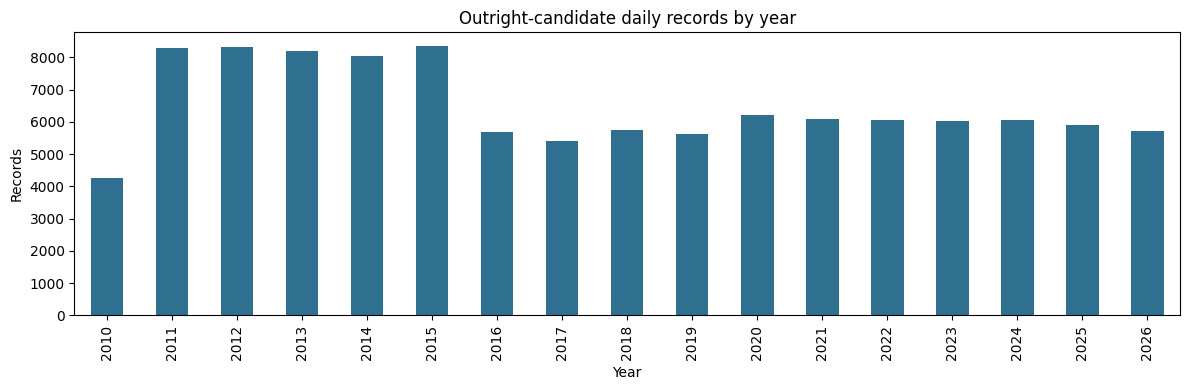

In [6]:
import matplotlib.pyplot as plt

annual_rows = outright.resample("YE").size()
annual_rows.index = annual_rows.index.year

ax = annual_rows.plot(kind="bar", figsize=(12, 4), color="#2f6f8f")
ax.set_title("Outright-candidate daily records by year")
ax.set_xlabel("Year")
ax.set_ylabel("Records")
plt.tight_layout()
plt.show()

## Findings before cleaning

- The raw file contains 777,383 daily records from June 6, 2010 through October 7, 2026.
- The file has no missing OHLCV values, missing symbols, duplicate timestamp/symbol rows, or zero-volume rows.
- The parent-level query includes many calendar spreads and related instruments, not only outright crude-oil contracts.
- The exploratory outright pattern identifies 109,962 rows across 136 displayed symbols and 248 instrument IDs.
- Negative closes are common in the full raw file because spread values can be negative. The outright candidate subset contains one negative close, which should be investigated separately rather than automatically removed.
- Raw symbols are reused across contract lifecycles. Contract identity must therefore use `instrument_id` together with the displayed symbol and timestamp.
- Databento reported some historical dates with reduced quality during download; those dates need to be documented and reviewed during preparation.

The next cleaning step should use instrument metadata to distinguish outright contracts from spreads, preserve `instrument_id`, validate contract date ranges, and save a processed dataset separately from the raw DBN file.